In [17]:
# --- 0) Imports & paths ---
import os, numpy as np, scanpy as sc
from anndata import AnnData
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# PyTorch imports
import torch
from torch.utils.data import TensorDataset, DataLoader

# Mixed diffusion imports
from mixed_diffusion.train import train
from mixed_diffusion.models.get_model import get_model
from mixed_diffusion.main_utils import get_device
from mixed_diffusion.config_manager import load_model_config
from mixed_diffusion.model_handler import load_existing_model
from mixed_diffusion.preprocessing.data_transformer import DataTransformer


In [18]:
def visualize_umap(X, y, points_to_plot=None, labels_to_plot=None):
    # --- UMAP visualization of synthetic data ---
    # Apply PCA first to reduce dimensionality
    pca = PCA(n_components=15)
    X_pca = pca.fit_transform(X)

    # Then apply UMAP on the PCA-reduced data
    um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0, metric="cosine").fit(X_pca)
    emb = um.embedding_

    if points_to_plot is not None:
        emb = um.transform(pca.transform(points_to_plot))
        y = np.array(labels_to_plot)

    # --- Plot the UMAP embedding ---
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
    ax.set_title("Synthetic Data UMAP Embedding")

    import matplotlib.colors as mcolors
    palette = list(mcolors.TABLEAU_COLORS.values())

    # Plot each class with different colors
    unique_labels = np.unique(y)
    for i, label in enumerate(unique_labels):
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], 
                s=20, alpha=0.7, 
                c=palette[i % len(palette)], 
                label=f'Class {label}')

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(True, alpha=0.2)
    ax.legend()

    plt.suptitle("Synthetic 2-Class Gaussian Data (UMAP)")
    plt.show()


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


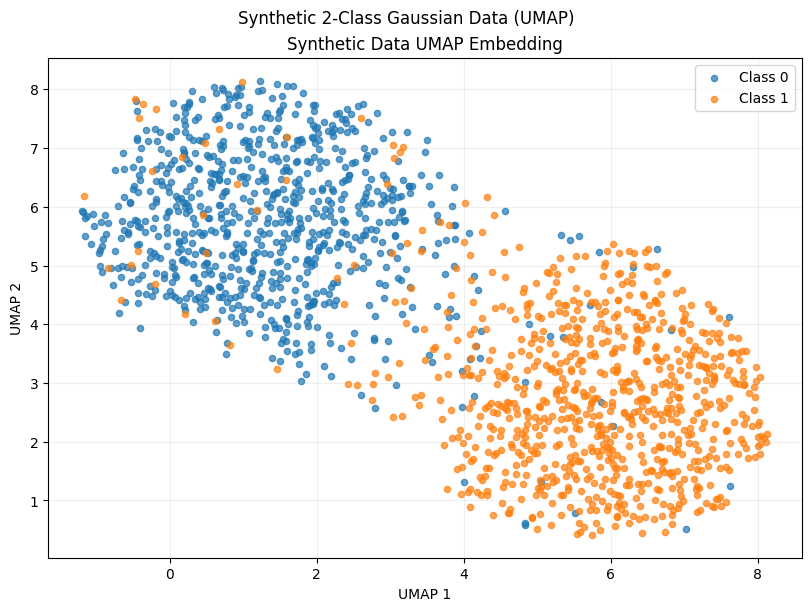

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


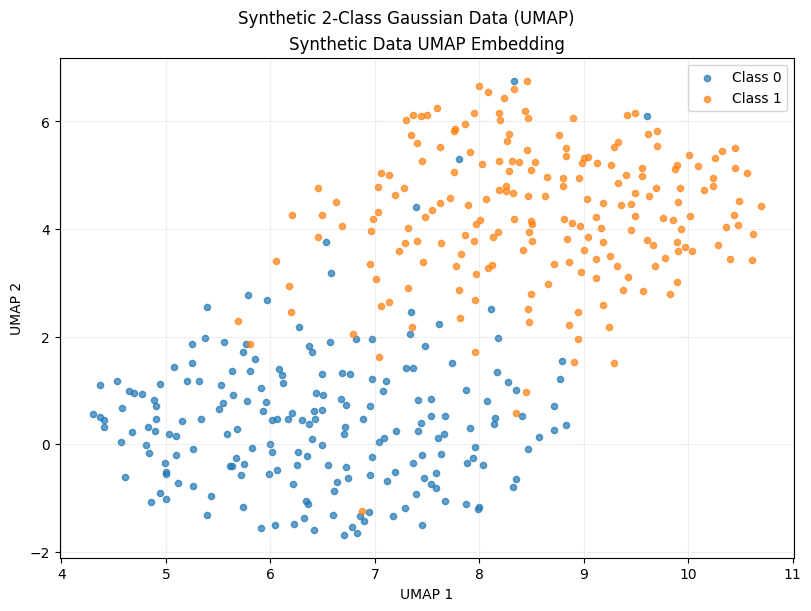

X_train_noisy.shape: (1600, 2000)
X_test.shape: (400, 2000)


In [19]:
# We have two 15d means
means = [[1] * 15, [0] * 15]
variance = [[1.3] * 15, [1.5] * 15]
stds = np.sqrt(variance)

# Sample data from the two Gaussians with labels
np.random.seed(42)  # For reproducibility

n_samples = 2000
n_classes = len(means)

p1, p2 = 0.5, 0.5  # must sum to 1

labels = np.random.choice([0, 1], size=n_samples, p=[p1, p2])

# Generate data using multivariate normal distribution
all_data = []
all_labels = []

for i in range(n_classes):
    # Number of samples for this class
    n_class_samples = (labels == i).sum()
    
    # Create covariance matrix (diagonal matrix from variances)
    cov_matrix = np.diag(variance[i])
    
    # Sample from multivariate normal distribution
    class_data = np.random.multivariate_normal(
        mean=means[i], 
        cov=cov_matrix, 
        size=n_class_samples
    )
    
    all_data.append(class_data)
    all_labels.append(np.full(n_class_samples, i))
    

U = np.vstack(all_data)

V_rows = 2000
V = np.random.multivariate_normal(np.zeros(15), np.eye(15), size=V_rows)

X_true = U @ V.T

# Create labels array from all_labels
y = np.concatenate(all_labels)

# Shuffle the data and labels together to mix the classes
shuffle_idx = np.random.permutation(len(X_true))
X_true = X_true[shuffle_idx]
y = y[shuffle_idx]

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_true, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class balance
)

X_train_noisy = X_train + np.random.normal(0, 1, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 10, X_test.shape)


visualize_umap(X_train_noisy, y_train)
visualize_umap(X_test_noisy, y_test)

print(f"X_train_noisy.shape: {X_train_noisy.shape}")
print(f"X_test.shape: {X_test_noisy.shape}")

In [20]:
# Create train/test split and save in CITEseq format
import pandas as pd

# Save in CITEseq format
# Save data as C_train.npy and C_test.npy
print(np.load("C_train.npy")[0,0])
np.save('C_train.npy', X_train_noisy)
print(np.load("C_train.npy")[0,0])

np.save('C_test.npy', X_test_noisy)

# Save labels as CSV files (matching CITEseq format)
# Create DataFrame with 'x' column to match CITEseq structure
labels_train_df = pd.DataFrame({'x': y_train})
labels_test_df = pd.DataFrame({'x': y_test})

labels_train_df.to_csv('labels_train.csv', index=False)
labels_test_df.to_csv('labels_test.csv', index=False)


-3.284016746189849
-3.284016746189849


In [21]:

X_test_noisy_as_train = X_test + np.random.normal(0, 1, X_test.shape)
np.save('C_test_noisy_as_train.npy', X_test_noisy_as_train)

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


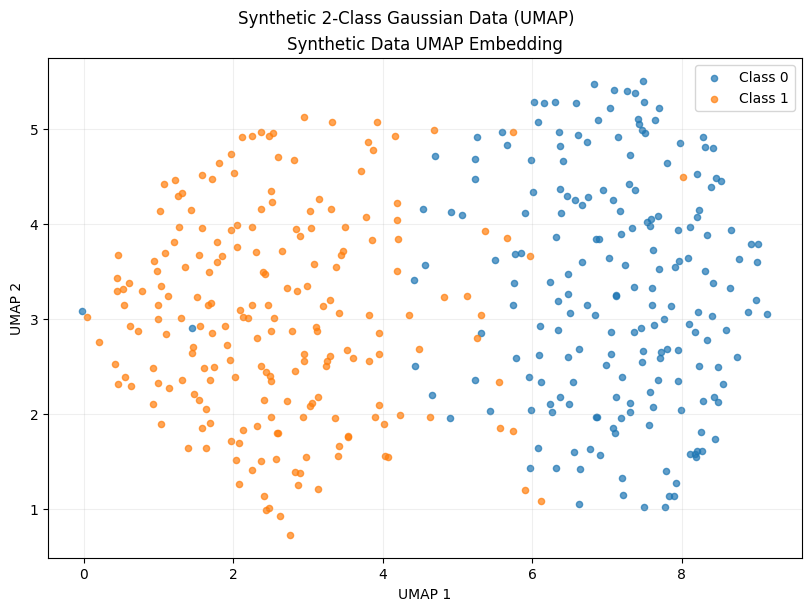

In [22]:
from scipy.stats import multivariate_t


X_train_noisy_multivariate = X_train + multivariate_t.rvs(size=X_train.shape[0], shape=np.eye(X_train.shape[1]), df=4)
X_test_noisy_multivariate = X_test + multivariate_t.rvs(size=X_test.shape[0], shape=np.eye(X_test.shape[1]), df=4)

visualize_umap(X_test_noisy_multivariate, y_test)

# Save multivariate noise versions
np.save('C_train_multivariate.npy', X_train_noisy_multivariate)
np.save('C_test_multivariate.npy', X_test_noisy_multivariate)


(2000, 2000)


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


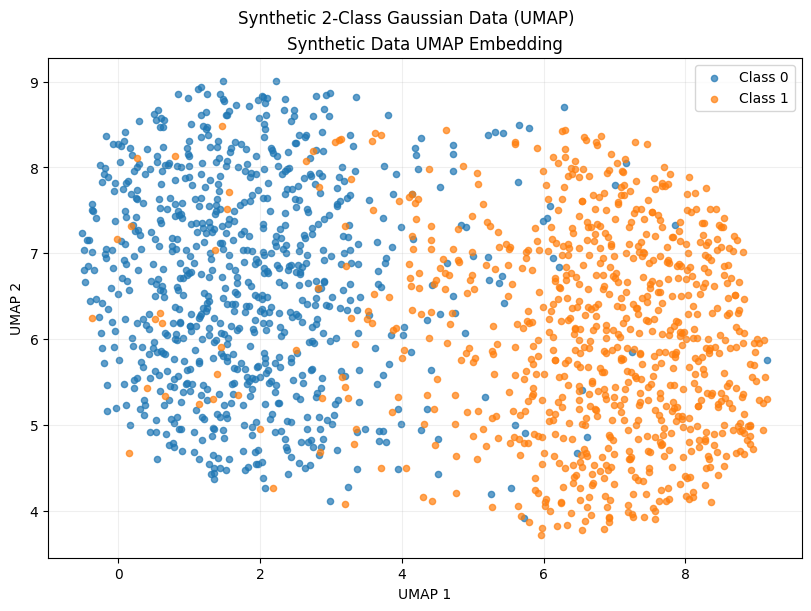

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


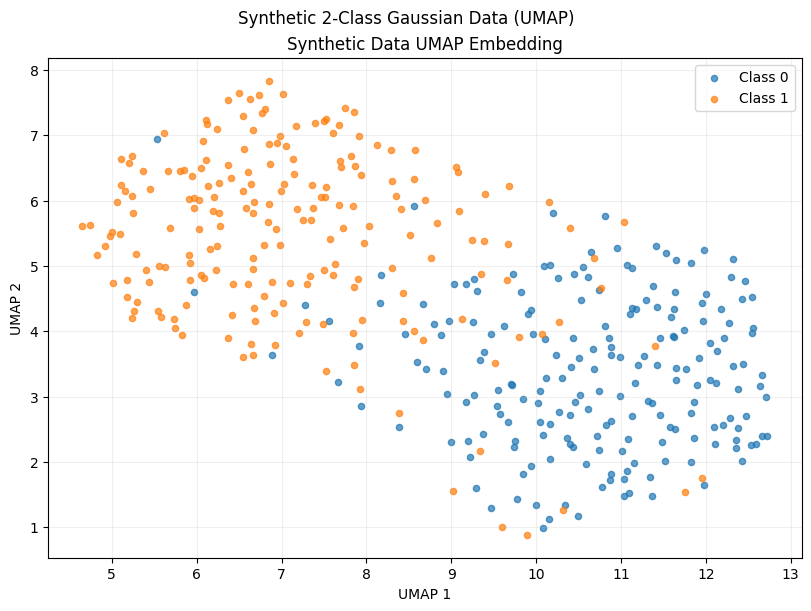

In [23]:
# Change U to be one component multivariate T

# Generate data using multivariate normal distribution
all_data = []
all_labels = []

for i in range(n_classes):
    # Number of samples for this class
    n_class_samples = (labels == i).sum()
    
    # Create covariance matrix (diagonal matrix from variances)
    cov_matrix = np.diag(variance[i])
    
    if i == 0:
        # Sample from multivariate normal distribution
        class_data = np.random.multivariate_normal(
            mean=means[i], 
            cov=cov_matrix, 
            size=n_class_samples
        )
    elif i == 1:
        class_data = multivariate_t.rvs(loc=means[i], size=n_class_samples, shape=cov_matrix, df=4)
    
    all_data.append(class_data)
    all_labels.append(np.full(n_class_samples, i))
    

U = np.vstack(all_data)

X_true_t_mixture = U @ V.T

print(X_true_t_mixture.shape)

# Create labels array from all_labels
y = np.concatenate(all_labels)

X_true_t_mixture = X_true_t_mixture[shuffle_idx]
y = y[shuffle_idx]

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_true_t_mixture, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class balance
)

X_train_noisy = X_train + np.random.normal(0, 1, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 10, X_test.shape)

visualize_umap(X_train_noisy, y_train)
visualize_umap(X_test_noisy, y_test)

In [35]:
# Save t_mixture noise versions
np.save('C_train_t_mixture.npy', X_train_noisy)
np.save('C_test_t_mixture.npy', X_test_noisy)

['alpha_0', 'alpha_10', 'alpha_20', 'alpha_30', 'alpha_40', 'alpha_50', 'alpha_60', 'alpha_70', 'alpha_80', 'alpha_90', 'alpha_100']
[[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
 [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
 [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7]
 [0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8]
 [0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9]
 [1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]]
U.shape: (11, 15)
V.shape: (2000, 15)
X_interpolated.shape: (11, 2000)


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


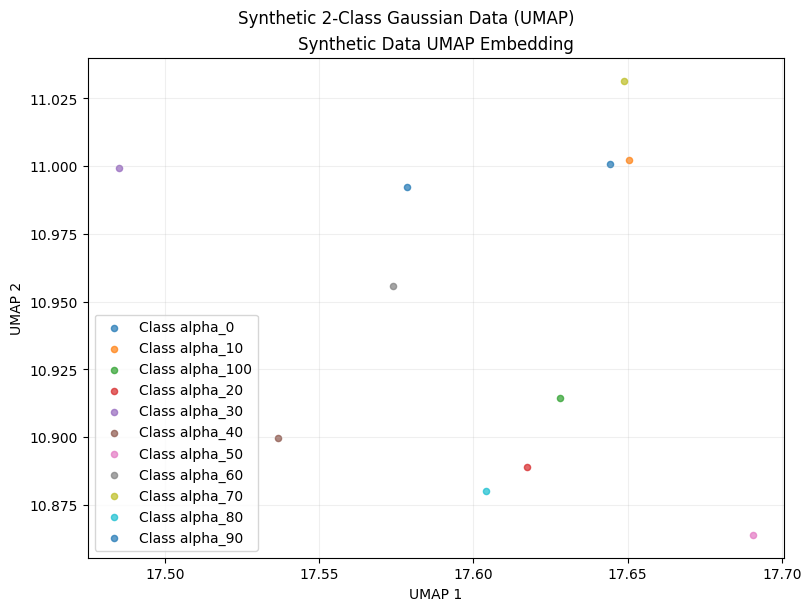

In [36]:
mean_i = np.array(means[0])
mean_j = np.array(means[1])

interpolated_data = []
interpolated_label = []
for alpha in np.arange(0.0, 1.1, 0.1):
    interpolated_point = mean_i * alpha + (1-alpha) * mean_j
    
    interpolated_data.append(interpolated_point)
    interpolated_label.append(f"alpha_{int(alpha*100)}")
    
print(interpolated_label)

U = np.vstack(interpolated_data)
print(U)

X_interpolated = U @ V.T

print(f"U.shape: {U.shape}")
print(f"V.shape: {V.shape}")
print(f"X_interpolated.shape: {X_interpolated.shape}")

visualize_umap(X_train, interpolated_label, points_to_plot=X_interpolated, labels_to_plot=np.array(interpolated_label))

np.save('C_test_interpolated.npy', X_interpolated)
pd.DataFrame(interpolated_label).to_csv('labels_interpolated.csv', index=False)

In [37]:
np.load("C_test_interpolated.npy")

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.7263352 , -0.24317208, -0.52640625, ..., -0.60234437,
         0.42755958,  0.59505916],
       [-1.45267039, -0.48634416, -1.05281251, ..., -1.20468874,
         0.85511916,  1.19011832],
       ...,
       [-5.81068156, -1.94537664, -4.21125003, ..., -4.81875497,
         3.42047666,  4.76047327],
       [-6.53701676, -2.18854872, -4.73765629, ..., -5.42109934,
         3.84803624,  5.35553243],
       [-7.26335195, -2.4317208 , -5.26406254, ..., -6.02344371,
         4.27559582,  5.95059159]])

In [38]:
means

[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

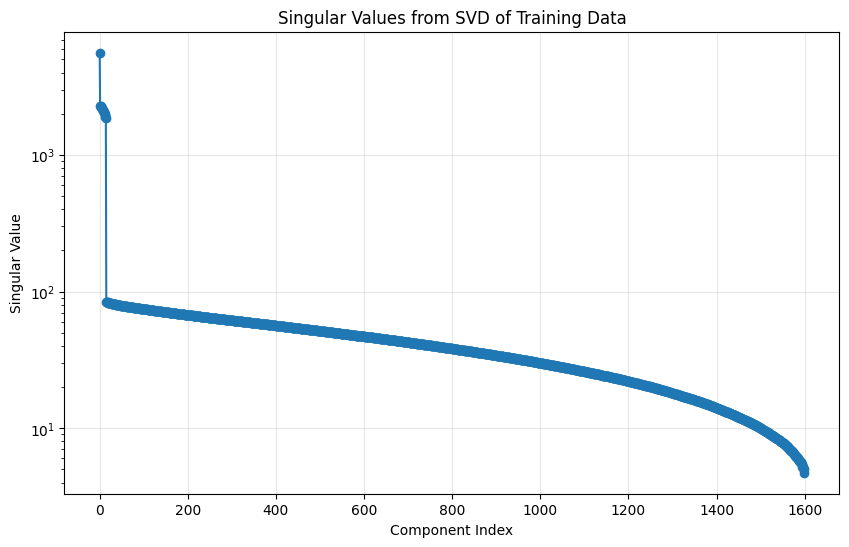

Shape of training data: (1600, 2000)
Number of singular values: 1600
Top 20 singular values: [5602.23789123 2295.0814629  2293.32127047 2243.18535177 2226.63775024
 2202.37855761 2155.61988971 2129.10491221 2096.04565485 2071.96765843
 2047.53338679 1998.77143833 1947.18635987 1904.76389352 1874.01470493
   84.10597263   84.01779679   83.62210949   83.36031129   83.04374216]


In [39]:
train = np.load("C_train.npy")

# Perform SVD
U_svd, s, Vt = np.linalg.svd(train, full_matrices=False)

# Plot singular values
plt.figure(figsize=(10, 6))
plt.plot(s, 'o-')
plt.title('Singular Values from SVD of Training Data')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Shape of training data: {train.shape}")
print(f"Number of singular values: {len(s)}")
print(f"Top 20 singular values: {s[:20]}")


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


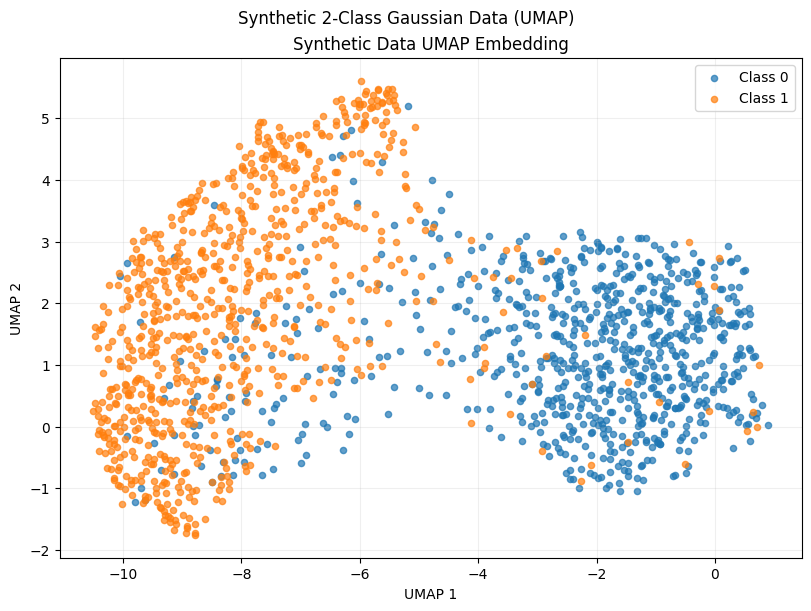

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


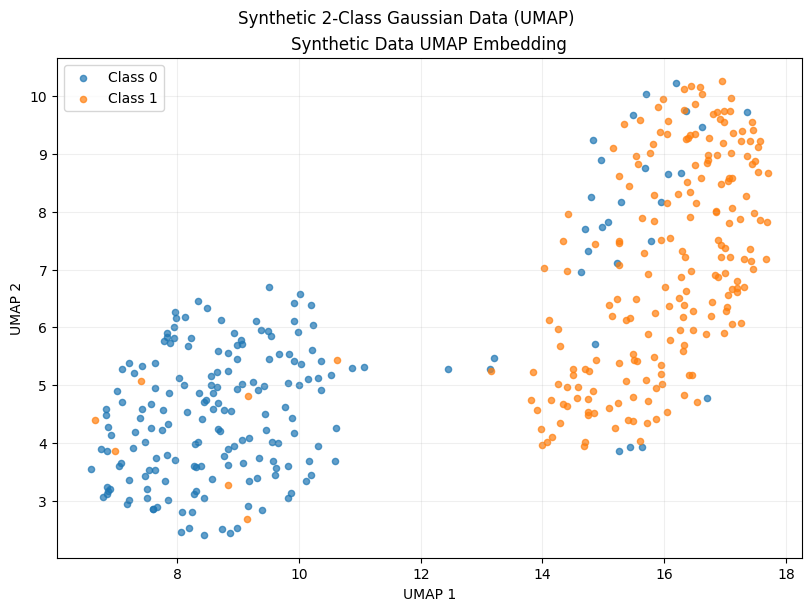

X_train_noisy.shape: (1600, 2000)
X_test.shape: (400, 2000)


In [40]:
# Do ablation with quadratic transformation
means = [[1] * 15, [0] * 15]
variance = [[1.3] * 15, [1.5] * 15]
stds = np.sqrt(variance)

# Sample data from the two Gaussians with labels
np.random.seed(42)  # For reproducibility

n_samples = 2000
n_classes = len(means)

p1, p2 = 0.5, 0.5  # must sum to 1

labels = np.random.choice([0, 1], size=n_samples, p=[p1, p2])

# Generate data using multivariate normal distribution
all_data = []
all_labels = []

for i in range(n_classes):
    # Number of samples for this class
    n_class_samples = (labels == i).sum()
    
    # Create covariance matrix (diagonal matrix from variances)
    cov_matrix = np.diag(variance[i])
    
    # Sample from multivariate normal distribution
    class_data = np.random.multivariate_normal(
        mean=means[i], 
        cov=cov_matrix, 
        size=n_class_samples
    )
    
    all_data.append(class_data)
    all_labels.append(np.full(n_class_samples, i))
    

U = np.vstack(all_data)

V_rows = 2000
V = np.random.multivariate_normal(np.zeros(15), np.eye(15), size=V_rows)

non_linearity_rho = .7

X_true = np.sqrt(1 - non_linearity_rho**2) * U @ V.T + non_linearity_rho * (U @ V.T)**2

# Create labels array from all_labels
y = np.concatenate(all_labels)

# Shuffle the data and labels together to mix the classes
shuffle_idx = np.random.permutation(len(X_true))
X_true = X_true[shuffle_idx]
y = y[shuffle_idx]

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_true, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class balance
)

X_train_noisy = X_train + np.random.normal(0, 1, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 10, X_test.shape)


visualize_umap(X_train_noisy, y_train)
visualize_umap(X_test_noisy, y_test)

print(f"X_train_noisy.shape: {X_train_noisy.shape}")
print(f"X_test.shape: {X_test_noisy.shape}")

In [41]:
# Save t_mixture noise versions
np.save('C_train_quadratic.npy', X_train_noisy)
np.save('C_test_quadratic.npy', X_test_noisy)

['alpha_0', 'alpha_10', 'alpha_20', 'alpha_30', 'alpha_40', 'alpha_50', 'alpha_60', 'alpha_70', 'alpha_80', 'alpha_90', 'alpha_100']
[[ 2.02730642  0.00487203 -0.96055826 -2.12923536 -0.9963443   2.22214516
  -0.97667241  0.82817414 -0.48889846  0.5007449  -0.47614365  0.98287861
   2.28057522 -0.350208    0.3668396 ]
 [ 0.36063254 -1.34288376 -0.28288739  0.36719005 -1.2027385  -0.02716265
   0.58930196  0.28277303 -0.27517582 -1.21794696  0.27229197 -0.38076947
   2.66694673 -1.2960951   0.36836159]
 [ 0.25771328  1.10456543 -0.7624501  -0.33741257  0.8298472  -1.30736002
  -1.28559713 -1.73425268 -1.58445744 -0.98462662  0.42732705  0.73319102
   0.75304646  1.51481729 -0.87694527]
 [ 1.03594142 -0.78688898 -1.46722515 -0.51258688 -1.51012473 -0.91147481
  -0.80779497  1.72493037 -0.56465408  0.03480335  1.24035349  1.55004459
  -0.71634917  1.50462842 -0.4992791 ]
 [ 0.7102257  -0.19244714 -0.12117914  0.14250836  0.67532998 -0.34224691
   0.67085847  0.13980803  1.09743617 -2.5841

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


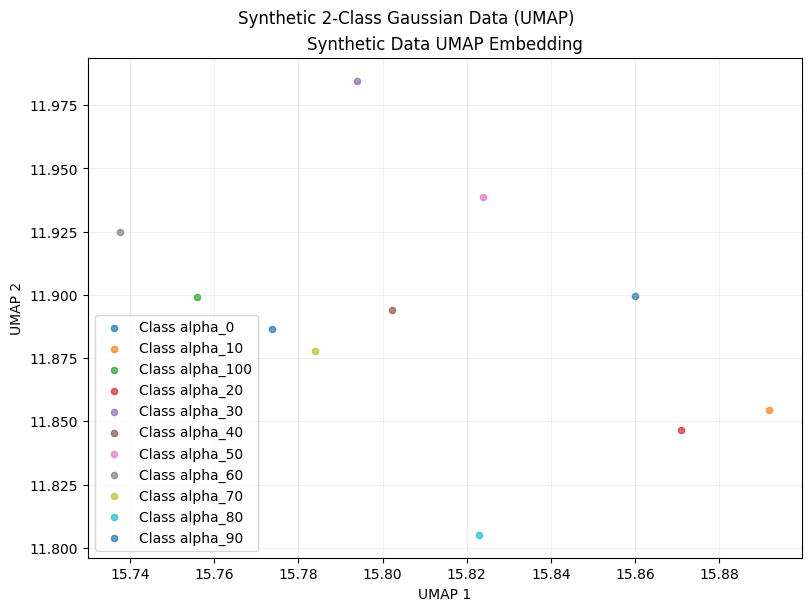

In [42]:
mean_i = np.array(means[0])
mean_j = np.array(means[1])

interpolated_data = []
interpolated_label = []
for alpha in np.arange(0.0, 1.1, 0.1):
    interpolated_point = mean_i * alpha + (1-alpha) * mean_j
    
    interpolated_data.append(interpolated_point + np.random.normal(0, 1, interpolated_point.shape))
    interpolated_label.append(f"alpha_{int(alpha*100)}")
    
print(interpolated_label)

U = np.vstack(interpolated_data)
print(U)

X_interpolated = U @ V.T

print(f"U.shape: {U.shape}")
print(f"V.shape: {V.shape}")
print(f"X_interpolated.shape: {X_interpolated.shape}")

visualize_umap(X_train, interpolated_label, points_to_plot=X_interpolated, labels_to_plot=np.array(interpolated_label))

np.save('C_test_interpolated_offset.npy', X_interpolated)
pd.DataFrame({'x': interpolated_label}).to_csv('labels_interpolated_offset.csv', index=False)

In [43]:
np.load("C_test_t_mixture.npy")

array([[ 16.67598719,  -0.94842882,   3.11172092, ...,  18.34141193,
        -15.1655918 ,  42.84768461],
       [-23.63885262,  73.26998773,  26.63421932, ...,  -8.92844587,
        -10.77455831,  -6.8328156 ],
       [  7.51379456, -18.37105096, 167.35262389, ...,  30.17487759,
        -12.29040261, 132.64720774],
       ...,
       [ -3.64577511,   5.27653948,  51.86522945, ...,  13.76394208,
         44.67612537,  14.97499972],
       [ 55.30038939,  40.59158683,   2.38514041, ...,  74.13798624,
          4.72767793,  18.03026188],
       [ 28.23395414,  63.108934  ,  10.48593603, ...,  -4.61803911,
         18.26869915,  12.67293614]])

In [44]:
np.load("C_test_multivariate.npy")

array([[ -1.64088791,  -4.29485804,  -3.77541536, ...,  -0.14287375,
         -3.90477566,  -6.11940151],
       [ -1.79716698, -10.24113058,  -6.4017138 , ...,   0.81873401,
          1.78251132,  -1.85688944],
       [ -4.3246773 ,  -0.49775986,  14.05725652, ...,  -7.27319616,
         -0.19348731, -10.94272932],
       ...,
       [  0.5443238 ,  -4.86935659,   5.53509659, ...,   0.92139952,
         -8.41442026,   0.76752022],
       [-11.65061725,   6.94007454,  -5.25874614, ..., -10.78744127,
          3.40618483,   4.00616322],
       [ -6.76415108,   7.84144161,  -4.51094184, ...,   1.825155  ,
          3.75444031,   2.21948654]])

In [45]:
X_test_noisy_multivariate

array([[ -1.64088791,  -4.29485804,  -3.77541536, ...,  -0.14287375,
         -3.90477566,  -6.11940151],
       [ -1.79716698, -10.24113058,  -6.4017138 , ...,   0.81873401,
          1.78251132,  -1.85688944],
       [ -4.3246773 ,  -0.49775986,  14.05725652, ...,  -7.27319616,
         -0.19348731, -10.94272932],
       ...,
       [  0.5443238 ,  -4.86935659,   5.53509659, ...,   0.92139952,
         -8.41442026,   0.76752022],
       [-11.65061725,   6.94007454,  -5.25874614, ..., -10.78744127,
          3.40618483,   4.00616322],
       [ -6.76415108,   7.84144161,  -4.51094184, ...,   1.825155  ,
          3.75444031,   2.21948654]])